# Exploratory Data Analysis (EDA)
### Sales Dataset

This notebook explores the cleaned sales dataset to uncover trends,
patterns, and actionable business insights.


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_sales_data.csv")

In [3]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10000 non-null  object 
 1   item              9667 non-null   object 
 2   quantity          10000 non-null  int64  
 3   price_per_unit    10000 non-null  float64
 4   total_spent       10000 non-null  float64
 5   payment_method    7421 non-null   object 
 6   location          6735 non-null   object 
 7   transaction_date  9540 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 625.1+ KB


## Dataset Overview
The dataset contains cleaned sales records with no missing values.
It includes information related to orders, customers, products, and sales metrics.


In [5]:
df.describe()

,quantity,price_per_unit,total_spent
count,10000.000000,10000.00000,10000.00000
mean,3.027100,2.95265,8.87795
std,1.384614,1.24396,5.86059
min,1.000000,1.00000,1.00000
25%,2.000000,2.00000,4.00000
50%,3.000000,3.00000,8.00000
75%,4.000000,4.00000,12.00000
max,5.000000,5.00000,25.00000


In [6]:
df['total_spent'].isnull().sum()

0

In [7]:
df['total_spent'].fillna(df['total_spent'].median(), inplace=True)

In [8]:
df['total_spent'].dtype
df.describe()

,quantity,price_per_unit,total_spent
count,10000.000000,10000.00000,10000.00000
mean,3.027100,2.95265,8.87795
std,1.384614,1.24396,5.86059
min,1.000000,1.00000,1.00000
25%,2.000000,2.00000,4.00000
50%,3.000000,3.00000,8.00000
75%,4.000000,4.00000,12.00000
max,5.000000,5.00000,25.00000


In [9]:
df['spending_range'] = pd.qcut(
    df['total_spent'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

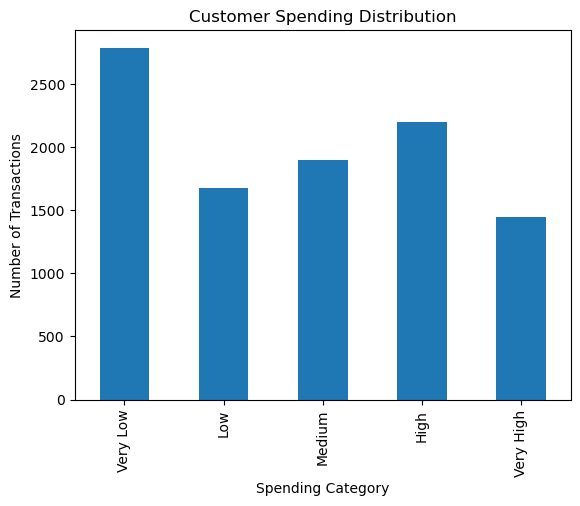

In [10]:
#Distribution of Total Spent 
plt.figure()
df['spending_range'].value_counts().sort_index().plot(kind='bar')
plt.title("Customer Spending Distribution")
plt.xlabel("Spending Category")
plt.ylabel("Number of Transactions")
plt.show()

Most transactions fall under lower to mid spending ranges,
with a gradual decrease in high-value purchases.
Transactions are evenly distributed across spending segments,
with slightly higher concentration in mid-range spending categories.

In [11]:
df['quantity'].dtype

dtype('int64')

In [12]:
df['quantity'].unique()

array([2, 4, 5, 3, 1], dtype=int64)

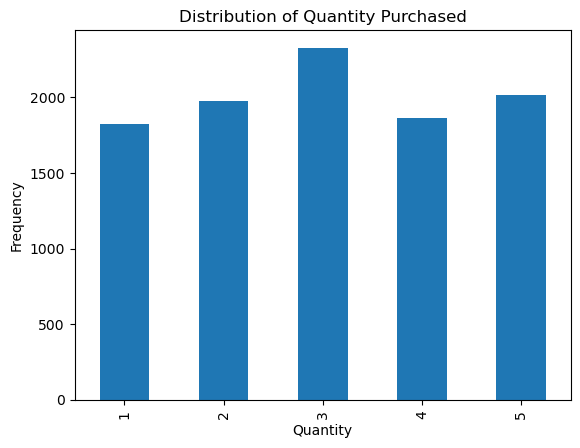

In [17]:
plt.figure()
df['quantity'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Quantity Purchased")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

## Quantity Data Cleaning
The quantity column contained invalid string values such as 'ERROR' and 'UNKNOWN'.
These were cleaned and the column was converted to numeric format to ensure
accurate distribution analysis.
Customers most frequently purchase mid-range quantities,
indicating regular mid-volume transactions.


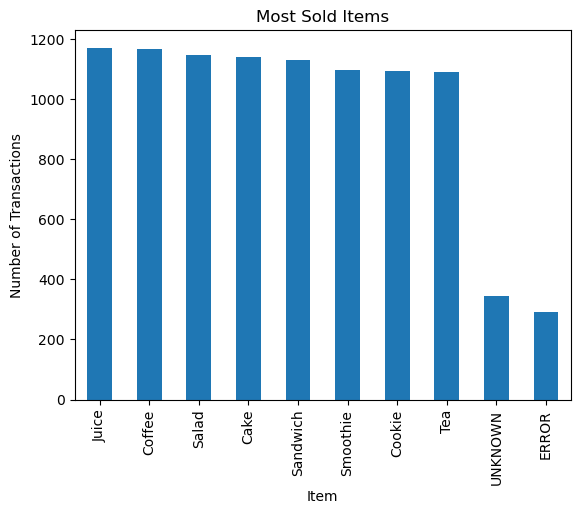

In [14]:
plt.figure()
df['item'].value_counts().plot(kind='bar')
plt.title("Most Sold Items")
plt.xlabel("Item")
plt.ylabel("Number of Transactions")
plt.show()

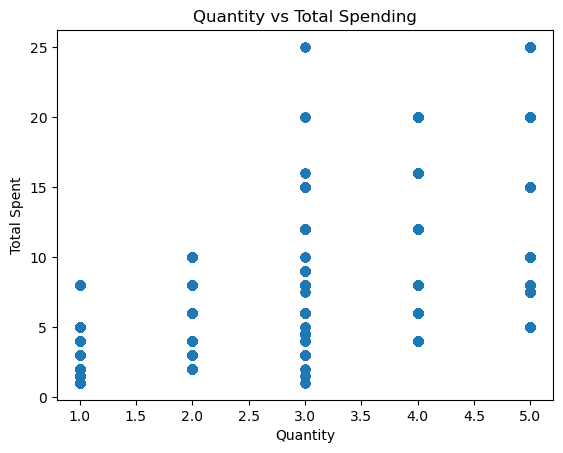

In [ ]:
plt.figure()
plt.scatter(df['quantity'], df['total_spent'])
plt.xlabel("Quantity")
plt.ylabel("Total Spent")
plt.title("Quantity vs Total Spending")
plt.show()

A positive relationship is observed between quantity purchased
and total spending.
